# Dark Matter Density vs. Velocity-Divergence Slice

This notebook compares a PyHermes dark-matter density-contrast field with the halo velocity-divergence field used in `weighted_fields.ipynb`. It assumes the dark-matter particles have already been projected on the server and downloaded as a cached `ConvolsData` file under `examples/output/`. The notebook loads that field locally, Gaussian-smooths it, and samples it on the same two-dimensional slice as the velocity-divergence field.

For a matter density contrast,

$$
\delta_m(\mathbf{x}) = \frac{\rho_m(\mathbf{x})}{\bar\rho_m} - 1.
$$

The linear continuity-equation expectation is

$$
\nabla\cdot\mathbf{v} \simeq -aHf\,\delta_m,
$$

so the dimensionless velocity-divergence proxy plotted below is

$$
\theta_v(\mathbf{x}) = -\frac{\nabla\cdot\mathbf{v}}{aHf/h}.
$$

The factor $h$ in the denominator converts the derivative length unit to `Mpc/h`, matching the coordinates used by the notebook. The plots below use the equivalent raw-units comparison,

$$
\nabla\cdot\mathbf{v} \quad \hbox{vs.}\quad -\frac{aHf}{h}\,\delta_m.
$$

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_repo_root(start=None):
    path = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (path, *path.parents):
        if (candidate / "pyhermes").is_dir() and (candidate / "examples").is_dir():
            return candidate
    raise RuntimeError("Could not find the PyHermes repository root from the current directory.")


repo_root = find_repo_root()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from pyhermes.base.convols import Convols
from pyhermes.io import read_particle_data
from pyhermes.io.convols import ConvolsData
from pyhermes.io.window import WindowFunc

examples_dir = repo_root / "examples"
os.chdir(examples_dir)

figs_dir = Path("figs")
output_dir = Path("output")
figs_dir.mkdir(exist_ok=True)
output_dir.mkdir(exist_ok=True)

print(f"Repository root: {repo_root}")
print(f"Working directory: {Path.cwd()}")

Repository root: /Users/xutengpeng/xutp/PycharmProjects/PyHermes
Working directory: /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples


## Parameters

`J=8` is used for both the halo velocity fields and the dark-matter density field. With a $1000\,h^{-1}{\rm Mpc}$ box this corresponds to a $256^3$ scaling grid. The Gaussian smoothing radius is kept equal to the velocity-field notebook default.

In [2]:
box_size = 1000.0
J = 8
threads = 8
smoothing_scale = 10.0  # Mpc/h
density_floor_fraction = 0.0

slice_z = 500.0
slice_grid_resolution = 256

halo_catalog_path = Path("data/quijote_halos/8000")
dm_convols_path = output_dir / "quijote_fiducial_8000_snap004_dm_sfc_J8.pkl"

# Quijote fiducial cosmology, used only for the velocity-divergence normalization.
omega_m0 = 0.3175
redshift = 0.0

base_params = {
    "box_size": box_size,
    "J": J,
    "wavelet_mode": "db2",
    "wavelet_level": 10,
    "phi_resolution": 1024,
}

win_gauss = WindowFunc(
    {"type": "gaussian", "len_args": {"R": smoothing_scale}},
    base_params,
    threads=threads,
)

print(f"PyHermes grid: J={J}, L={2**J}, dx={box_size / 2**J:.3f} Mpc/h")
print(f"Gaussian smoothing scale: R={smoothing_scale:g} Mpc/h")
print(f"DM ConvolsData cache: {dm_convols_path}")

PyHermes grid: J=8, L=256, dx=3.906 Mpc/h
Gaussian smoothing scale: R=10 Mpc/h
DM ConvolsData cache: output/quijote_fiducial_8000_snap004_dm_sfc_J8.pkl


In [3]:
def build_field(pos, field_value=None, weight_normalization="catalog", fout_path=None, save_result=False, overwrite=False):
    task_params = {**base_params, "weight_normalization": weight_normalization}
    if fout_path is not None:
        task_params["fout_path"] = str(fout_path)

    task = Convols({"Convols": task_params})
    task.particle_pos = np.ascontiguousarray(np.array(pos, copy=True), dtype=np.float32)
    if field_value is not None:
        task.field_value = np.ascontiguousarray(np.array(field_value, copy=True), dtype=np.float32)
    task.threads = threads
    return task.run(save_result=save_result, overwrite=overwrite)


def load_dm_convols():
    if not dm_convols_path.exists():
        raise FileNotFoundError(
            f"Missing cached DM ConvolsData: {dm_convols_path}. "
            "Build it on the server with examples/scripts/build_quijote_dm_convols.py, "
            "then download it into examples/output/."
        )
    print(f"Loading cached DM ConvolsData: {dm_convols_path}")
    return ConvolsData(data_path=str(dm_convols_path), threads=threads)


dm_count_data = load_dm_convols()
if int(dm_count_data.J) != J or not np.isclose(float(dm_count_data.box_size), box_size):
    raise ValueError(
        f"Cached DM field has J={dm_count_data.J}, box_size={dm_count_data.box_size}; "
        f"expected J={J}, box_size={box_size}. Rebuild the server-side cache or change dm_convols_path."
    )
print("DM field:", f"L={dm_count_data.L}", f"particles={dm_count_data.particle_count}")

Loading cached DM ConvolsData: output/quijote_fiducial_8000_snap004_dm_sfc_J8.pkl
12:21:24 - INFO - pyhermes.io.base:ConvolsData - Reading Convols data from ---> output/quijote_fiducial_8000_snap004_dm_sfc_J8.pkl <---
12:21:24 - INFO - pyhermes.io.base:ConvolsData - epsilon: Shape(256, 256, 256), Min = -4.192e-06, Max = 3.069e-05, Mean = 5.96e-08, Sum = 1
DM field: L=256 particles=134217728


## Dark-Matter Density Contrast

The saved field is the unsmoothed `ConvolsData`. For the comparison we apply the same Gaussian window as the velocity field and then convert the smoothed density field to a dimensionless contrast.

In [4]:
dm_density_smoothed = dm_count_data @ win_gauss
dm_mean_density = dm_density_smoothed.field_mean_density(value_unit="grid")
dm_delta_data = dm_density_smoothed / dm_mean_density - 1.0

print(f"Smoothed DM mean density in grid units: {dm_mean_density:.6e}")

Smoothed DM mean density in grid units: 5.960464e-08


## Halo Velocity-Divergence Field

This section mirrors the derivative-window construction in `weighted_fields.ipynb`. The halo tracer density $n_h$ and the three velocity-weighted fields $n_{v_i}$ are Gaussian-smoothed first. The velocity field is then

$$
v_i(\mathbf{x}) = \frac{n_{v_i}(\mathbf{x})}{n_h(\mathbf{x})},
$$

and its derivative is computed with the quotient rule.

In [5]:
halo_reader_params = {
    "snapnum": 4,
    "redshift": redshift,
    "fields": {
        "vx": "vel_x",
        "vy": "vel_y",
        "vz": "vel_z",
        "mass": "mass",
    },
}

halo_data = read_particle_data(str(halo_catalog_path), data_format="fof", **halo_reader_params)
print(f"Halos loaded: {halo_data['pos'].shape[0]:,}")

halo_count_data = build_field(halo_data["pos"]) @ win_gauss
halo_velocity_data = [
    build_field(halo_data["pos"], field_value=halo_data[key]) @ win_gauss
    for key in ["vx", "vy", "vz"]
]

12:21:25 - INFO - pyhermes.io.readers:read_particle_data - Selected input particle format: fof
12:21:25 - INFO - pyhermes.io.readers:read_fof - Reading Quijote FoF halo data from ---> data/quijote_halos/8000 <---
Halos loaded: 406,728
12:21:25 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
12:21:25 - INFO - pyhermes.pipeline.pipeline:Convols - Convols runtime configuration: running on 1 MPI ranks with 8 threads per rank
12:21:25 - INFO - pyhermes.pipeline.pipeline:Convols - Preparing Convols input fields ...
12:21:25 - INFO - pyhermes.pipeline.pipeline:Convols - J=8, L=256, box_size=1000.0, phi_resolution=1024, wavelet_mode=db2, wavelet_level=10
12:21:25 - INFO - pyhermes.pipeline.pipeline:Convols - No catalog_weight provided; using unit catalogue weights for 406728 particles.
12:21:25 - INFO - pyhermes.pipeline.pipeline:Convols - Input particles ready | source=custom particle_pos array | particle_count=406728 | catalog_weight_key=None | field

In [6]:
deriv_physical_factor = halo_count_data.scale_factor


def make_derivative_window(nx, ny, nz):
    return WindowFunc(
        {
            "type": "directional_derivative",
            "los_args": {"nx": nx, "ny": ny, "nz": nz},
        },
        halo_count_data.convols_info,
        threads=threads,
    )


derivative_windows = [
    make_derivative_window(1.0, 0.0, 0.0),
    make_derivative_window(0.0, 1.0, 0.0),
    make_derivative_window(0.0, 0.0, 1.0),
]


def sample_fields_at_pos(field_data_list, pos):
    return np.vstack([
        field_data.field_density_at_pos(pos, value_unit="physical").astype(np.float64)
        for field_data in field_data_list
    ])


def sample_directional_derivatives(field_data_list, pos):
    gradient = np.empty((len(field_data_list), 3, pos.shape[0]), dtype=np.float64)
    for component_index, field_data in enumerate(field_data_list):
        for direction_index, window in enumerate(derivative_windows):
            gradient[component_index, direction_index] = (
                (field_data @ window).field_density_at_pos(pos, value_unit="physical").astype(np.float64)
                * deriv_physical_factor
            )
    return gradient


def velocity_divergence_at_pos(pos):
    n_values = halo_count_data.field_density_at_pos(pos, value_unit="physical").astype(np.float64)
    density_floor = density_floor_fraction * np.max(np.abs(n_values))
    density_mask = np.abs(n_values) > density_floor

    inv_n = np.zeros_like(n_values)
    np.divide(1.0, n_values, out=inv_n, where=density_mask)

    nv_values = sample_fields_at_pos(halo_velocity_data, pos)
    dn_values = sample_directional_derivatives([halo_count_data], pos)[0]
    dnv_values = sample_directional_derivatives(halo_velocity_data, pos)

    velocity_gradient = (
        dnv_values * inv_n[None, None, :]
        - nv_values[:, None, :] * dn_values[None, :, :] * inv_n[None, None, :]**2
    )
    divergence = velocity_gradient[0, 0] + velocity_gradient[1, 1] + velocity_gradient[2, 2]
    return divergence, density_mask

## Same-Slice Evaluation

Both fields are evaluated on the same $z={\rm const}$ grid. The comparison below is in raw velocity-divergence units: the measured halo velocity divergence is compared with the linear-theory prediction from the dark-matter density field, $-(aHf/h)\,\delta_m$.

In [7]:
slice_axis = ((np.arange(slice_grid_resolution, dtype=np.float32) + 0.5) * box_size / slice_grid_resolution) % box_size
slice_x, slice_y = np.meshgrid(slice_axis, slice_axis, indexing="ij")
slice_eval_pos = np.column_stack([
    slice_x.ravel(),
    slice_y.ravel(),
    np.full(slice_x.size, slice_z, dtype=np.float32),
]).astype(np.float32)

v_div_slice, velocity_slice_mask = velocity_divergence_at_pos(slice_eval_pos)
dm_delta_slice = dm_delta_data.field_density_at_pos(slice_eval_pos, value_unit="grid").astype(np.float64)

a = 1.0 / (1.0 + redshift)
E_z = np.sqrt(omega_m0 * (1.0 + redshift)**3 + (1.0 - omega_m0))
omega_m_z = omega_m0 * (1.0 + redshift)**3 / E_z**2
f_growth = omega_m_z**0.55
vdiv_to_delta = a * 100.0 * E_z * f_growth  # (km/s)/(Mpc/h)

theta_v_slice = np.full_like(v_div_slice, np.nan, dtype=np.float64)
theta_v_slice[velocity_slice_mask] = -v_div_slice[velocity_slice_mask] / vdiv_to_delta
dm_vdiv_prediction_slice = -dm_delta_slice * vdiv_to_delta

valid = velocity_slice_mask & np.isfinite(theta_v_slice) & np.isfinite(dm_delta_slice) & np.isfinite(v_div_slice)
corr = np.corrcoef(dm_delta_slice[valid], theta_v_slice[valid])[0, 1]
corr_vdiv = np.corrcoef(dm_vdiv_prediction_slice[valid], v_div_slice[valid])[0, 1]

theta_v_grid = theta_v_slice.reshape(slice_x.shape)
dm_delta_grid = dm_delta_slice.reshape(slice_x.shape)
v_div_grid = v_div_slice.reshape(slice_x.shape)
dm_vdiv_prediction_grid = dm_vdiv_prediction_slice.reshape(slice_x.shape)

print(f"aHf/h normalization: {vdiv_to_delta:.3f} (km/s)/(Mpc/h)")
print(f"Valid comparison pixels: {valid.sum():,} / {valid.size:,}")
print(f"Pearson r(theta_v, delta_m): {corr:.4f}")
print(f"Pearson r(v_div, -delta_m * aHf/h): {corr_vdiv:.4f}")

aHf/h normalization: 53.206 (km/s)/(Mpc/h)
Valid comparison pixels: 65,536 / 65,536
Pearson r(theta_v, delta_m): 0.8592
Pearson r(v_div, -delta_m * aHf/h): 0.8592


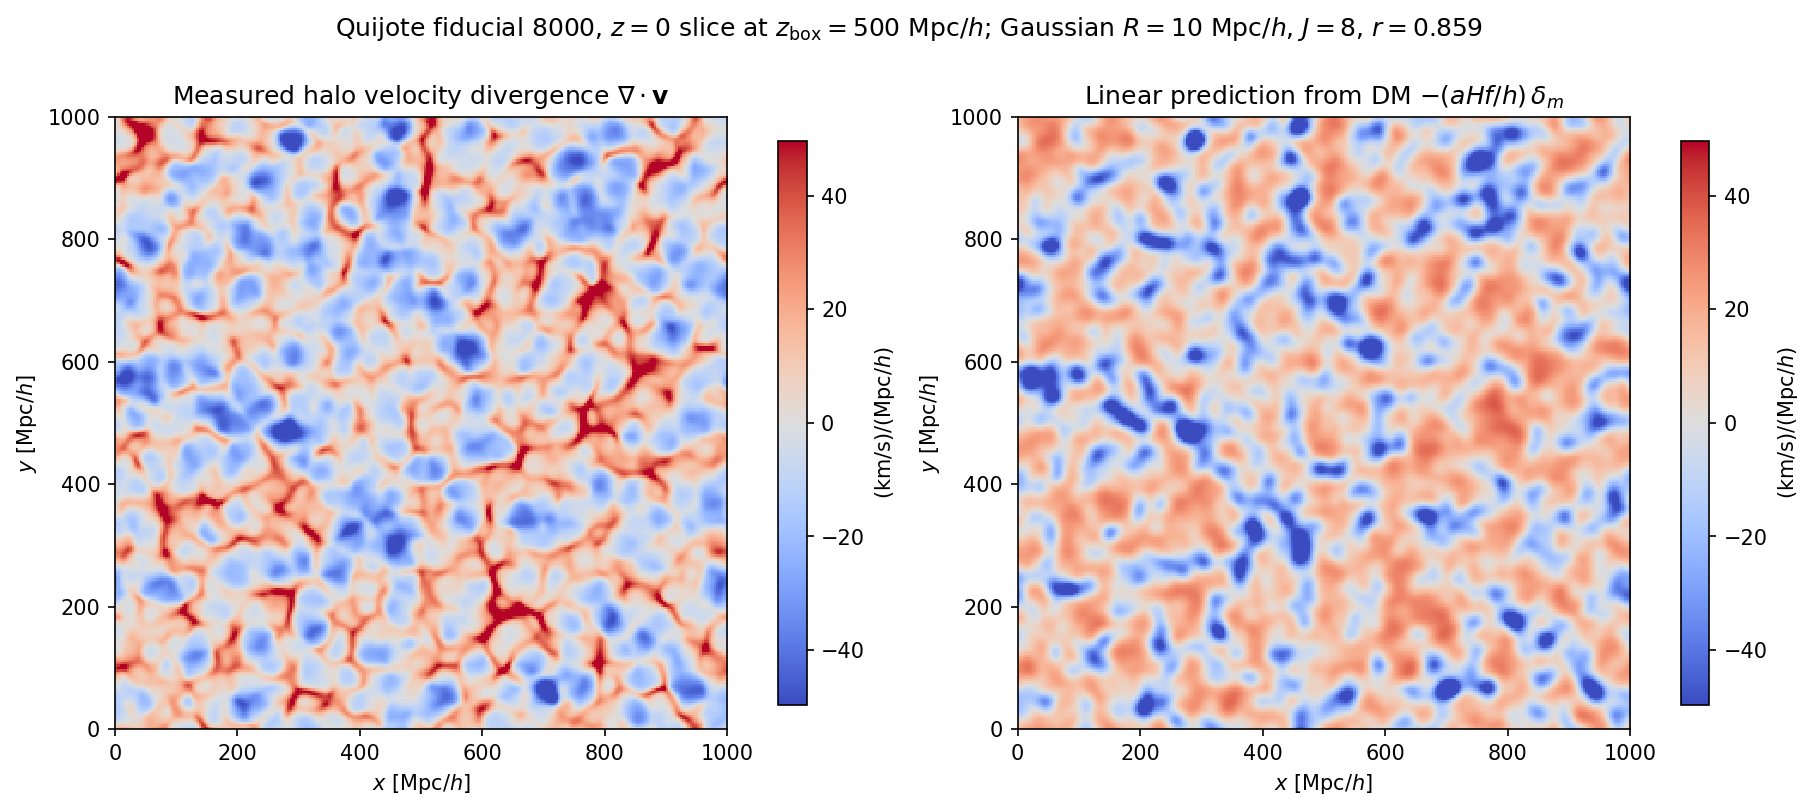

In [8]:
plot_values = np.concatenate([v_div_slice[valid], dm_vdiv_prediction_slice[valid]])
plot_limit = np.nanpercentile(np.abs(plot_values), 98)
if not np.isfinite(plot_limit) or plot_limit == 0.0:
    plot_limit = 1.0

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), dpi=150, constrained_layout=True)

for ax, grid, title in zip(
    axes,
    [v_div_grid, dm_vdiv_prediction_grid],
    [
        r"Measured halo velocity divergence $\nabla\cdot\mathbf{v}$",
        r"Linear prediction from DM $-(aHf/h)\,\delta_m$",
    ],
):
    im = ax.imshow(
        grid.T,
        origin="lower",
        extent=(0.0, box_size, 0.0, box_size),
        cmap="coolwarm",
        vmin=-plot_limit,
        vmax=plot_limit,
        interpolation="nearest",
    )
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x\ [{\rm Mpc}/h]$")
    ax.set_ylabel(r"$y\ [{\rm Mpc}/h]$")
    ax.set_title(title)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r"$({\rm km}/{\rm s})/({\rm Mpc}/h)$")

fig.suptitle(
    fr"Quijote fiducial 8000, $z={redshift:g}$ slice at $z_{{\rm box}}={slice_z:.0f}\ {{\rm Mpc}}/h$; "
    fr"Gaussian $R={smoothing_scale:g}\ {{\rm Mpc}}/h$, $J={J}$, $r={corr_vdiv:.3f}$",
    y=1.03,
)
fig.savefig(figs_dir / "dm_scaled_delta_velocity_divergence_slice_J8.png", dpi=200, bbox_inches="tight")
plt.show()

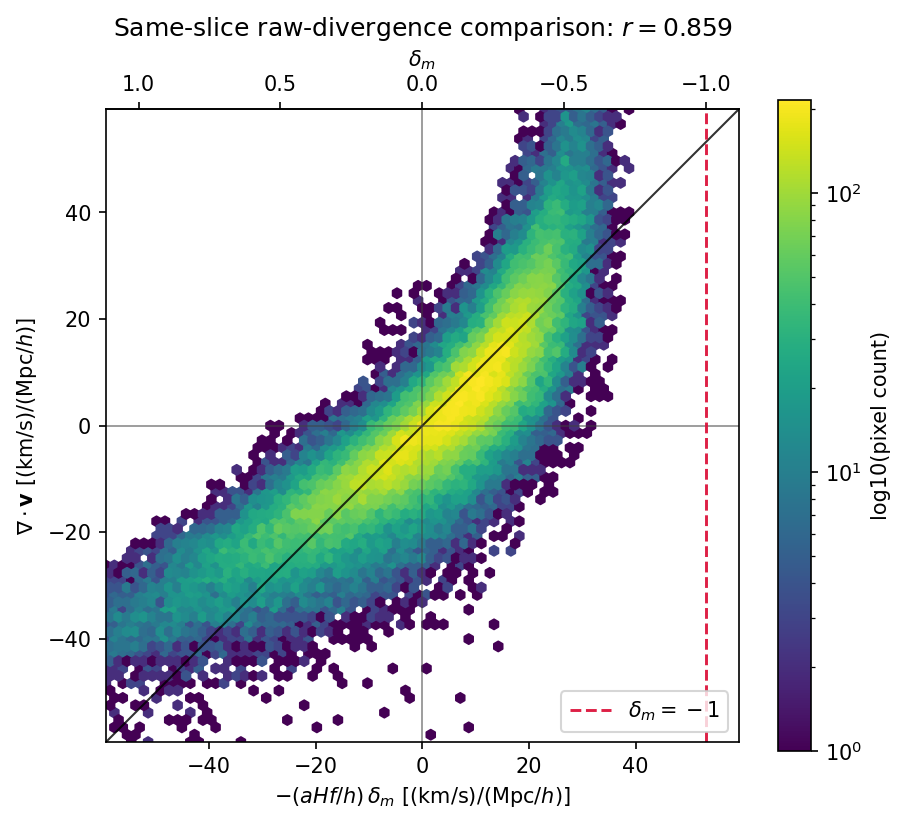

In [9]:
prediction_plot = dm_vdiv_prediction_slice[valid]
vdiv_plot = v_div_slice[valid]
scatter_limit = np.nanpercentile(np.abs(np.concatenate([prediction_plot, vdiv_plot])), 99)
if not np.isfinite(scatter_limit) or scatter_limit == 0.0:
    scatter_limit = 1.0
delta_minus_one_x = vdiv_to_delta
scatter_limit = max(scatter_limit, 1.05 * abs(delta_minus_one_x))

fig, ax = plt.subplots(figsize=(6.2, 5.4), dpi=150)
hb = ax.hexbin(
    prediction_plot,
    vdiv_plot,
    gridsize=75,
    bins="log",
    mincnt=1,
    cmap="viridis",
    extent=(-scatter_limit, scatter_limit, -scatter_limit, scatter_limit),
)
ax.plot([-scatter_limit, scatter_limit], [-scatter_limit, scatter_limit], color="k", lw=1, alpha=0.8)
ax.axhline(0.0, color="0.25", lw=0.8, alpha=0.6)
ax.axvline(0.0, color="0.25", lw=0.8, alpha=0.6)
ax.axvline(delta_minus_one_x, color="crimson", ls="--", lw=1.4, alpha=0.95, label=r"$\delta_m=-1$")
ax.set_xlim(-scatter_limit, scatter_limit)
ax.set_ylim(-scatter_limit, scatter_limit)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$-(aHf/h)\,\delta_m\ [({\rm km}/{\rm s})/({\rm Mpc}/h)]$")
ax.set_ylabel(r"$\nabla\cdot\mathbf{v}\ [({\rm km}/{\rm s})/({\rm Mpc}/h)]$")
ax.set_title(fr"Same-slice raw-divergence comparison: $r={corr_vdiv:.3f}$")
top_ax = ax.secondary_xaxis(
    "top",
    functions=(lambda x: -x / vdiv_to_delta, lambda delta: -delta * vdiv_to_delta),
)
top_ax.set_xlabel(r"$\delta_m$")
top_ax.set_xticks([-1.0, -0.5, 0.0, 0.5, 1.0])
ax.legend(loc="lower right", frameon=True)
cbar = fig.colorbar(hb, ax=ax)
cbar.set_label("log10(pixel count)")

plt.tight_layout()
fig.savefig(figs_dir / "dm_scaled_delta_velocity_divergence_hexbin_J8.png", dpi=200, bbox_inches="tight")
plt.show()